In [1]:
import pandas as pd
import numpy as np

In [ ]:
employees = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Employees")
departments = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Departments")
locations = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Locations")
jobs = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Jobs")
attendance = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Attendance")
attrition = pd.read_excel("hr_multi_sheet_dataset.xlsx",sheet_name="Attrition")

In [3]:
employees.head(10)

,EmployeeID,EmpCode,DeptID,LocationID,JobID,HireDate,Age,Gender,EmploymentStatus,Salary,PerformanceRating,TrainingHours,AbsenteeismDays,OvertimeHours,EngagementScore,SatisfactionScore,YearsSincePromotion,Bonus,ManagerID
0,1,E0001,6,1,1,2021-01-31,36,Male,Active,644704,1,8,5,24,90.3,3.4,0,46893,19
1,2,E0002,4,1,1,2019-01-19,34,Male,Active,742129,1,8,8,13,78.5,3.2,1,50055,23
2,3,E0003,6,4,4,2023-01-14,58,Female,Active,921776,1,2,0,0,65.3,2.8,5,80027,14
3,4,E0004,3,3,3,2020-05-31,42,Male,Active,368277,1,5,1,32,69.3,3.7,6,967,12
4,5,E0005,5,3,1,2026-03-08,50,Male,On Leave,551005,4,1,6,6,76.5,3.1,4,38246,10
5,6,E0006,6,3,4,2025-11-25,25,Male,Active,845846,3,1,11,17,59.3,4.3,6,43250,8
6,7,E0007,1,4,5,2023-02-01,44,Male,Active,818797,2,4,0,4,74.4,4.2,5,68931,22
7,8,E0008,6,1,3,2023-12-28,36,Male,Active,439591,3,8,5,3,63.4,3.2,1,56309,22
8,9,E0009,3,1,4,2018-05-12,41,Female,Active,930925,2,5,0,21,67.4,3.1,1,86707,21
9,10,E0010,4,4,8,2019-08-09,37,Male,Active,272789,5,8,8,9,68.3,3.9,2,41334,24


In [4]:
employees.dtypes

EmployeeID                      int64
EmpCode                           str
DeptID                          int64
LocationID                      int64
JobID                           int64
HireDate               datetime64[us]
Age                             int64
Gender                            str
EmploymentStatus                  str
Salary                          int64
PerformanceRating               int64
TrainingHours                   int64
AbsenteeismDays                 int64
OvertimeHours                   int64
EngagementScore               float64
SatisfactionScore             float64
YearsSincePromotion             int64
Bonus                           int64
ManagerID                       int64
dtype: object

In [5]:
departments.head(10)

,DeptID,Department,Budget_USD,Headcount_Target
0,1,HR,300000,25
1,2,Finance,500000,30
2,3,IT,900000,60
3,4,Sales,700000,55
4,5,Marketing,450000,28
5,6,Operations,650000,40


In [6]:
locations.head(10)

,LocationID,City,State,Region
0,1,Noida,UP,North
1,2,Lucknow,UP,North
2,3,Delhi,Delhi,North
3,4,Jaipur,Rajasthan,West


In [7]:
jobs.head(10)

,JobID,JobTitle,Grade,BaseSalaryBand
0,1,Analyst,G4,600000
1,2,Manager,G7,1200000
2,3,Executive,G3,450000
3,4,Engineer,G5,900000
4,5,Specialist,G5,800000
5,6,Associate,G2,350000
6,7,Lead,G6,1100000
7,8,Intern,G1,180000


In [8]:
attendance.head(10)

,EmployeeID,DaysPresent,LeavesTaken,WFHDays,LateMarks
0,1,205,10,7,6
1,2,252,7,15,8
2,3,223,8,15,11
3,4,242,14,5,11
4,5,225,5,4,11
5,6,249,15,5,8
6,7,187,1,2,10
7,8,186,0,13,2
8,9,260,7,2,11
9,10,199,0,6,8


In [9]:
attrition.head(10)

,EmployeeID,ExitReason,NoticePeriodDays
0,14,Relocation,59
1,15,Relocation,15
2,17,Pay,20
3,35,Relocation,90
4,37,Higher Studies,5
5,38,Manager,41
6,49,Manager,11
7,50,Manager,45
8,53,Career Growth,65
9,55,Pay,86


In [14]:
df = employees.merge(departments,on='DeptID')
df = df.merge(locations,on="LocationID")
df = df.merge(jobs,on="JobID")
df = df.merge(attendance,on="EmployeeID")
df = df.merge(attrition,on="EmployeeID",how='left')

In [15]:
df.shape

(230, 34)

In [16]:
df['Attrited'] = df['EmployeeID'].isin(attrition['EmployeeID']).astype(int)

In [19]:
df.tail(10)

,EmployeeID,EmpCode,DeptID,LocationID,JobID,HireDate,Age,Gender,EmploymentStatus,Salary,...,JobTitle,Grade,BaseSalaryBand,DaysPresent,LeavesTaken,WFHDays,LateMarks,ExitReason,NoticePeriodDays,Attrited
220,221,E0221,2,3,6,2020-08-28,40,Male,On Leave,355098,...,Associate,G2,350000,227,14,2,9,NaN,NaN,0
221,222,E0222,3,1,3,2025-01-08,48,Female,Active,365459,...,Executive,G3,450000,192,4,20,6,NaN,NaN,0
222,223,E0223,3,4,7,2019-09-04,40,Female,Active,1080790,...,Lead,G6,1100000,189,1,13,10,NaN,NaN,0
223,224,E0224,3,2,8,2018-08-25,56,Female,On Leave,180000,...,Intern,G1,180000,196,7,9,4,NaN,NaN,0
224,225,E0225,2,3,4,2021-09-14,26,Female,Resigned,985459,...,Engineer,G5,900000,220,12,10,5,Career Growth,70.0,1
225,226,E0226,1,3,7,2025-07-22,23,Male,Active,994689,...,Lead,G6,1100000,237,8,7,1,NaN,NaN,0
226,227,E0227,2,3,5,2018-03-04,34,Male,On Leave,750837,...,Specialist,G5,800000,205,4,18,1,NaN,NaN,0
227,228,E0228,5,2,7,2020-09-07,56,Female,Active,1110762,...,Lead,G6,1100000,199,3,5,7,NaN,NaN,0
228,229,E0229,3,3,5,2022-01-13,53,Female,Active,760104,...,Specialist,G5,800000,239,10,13,1,NaN,NaN,0
229,230,E0230,3,4,1,2024-04-23,35,Male,Active,732405,...,Analyst,G4,600000,248,11,6,7,NaN,NaN,0


In [20]:
df.columns

Index(['EmployeeID', 'EmpCode', 'DeptID', 'LocationID', 'JobID', 'HireDate',
       'Age', 'Gender', 'EmploymentStatus', 'Salary', 'PerformanceRating',
       'TrainingHours', 'AbsenteeismDays', 'OvertimeHours', 'EngagementScore',
       'SatisfactionScore', 'YearsSincePromotion', 'Bonus', 'ManagerID',
       'Department', 'Budget_USD', 'Headcount_Target', 'City', 'State',
       'Region', 'JobTitle', 'Grade', 'BaseSalaryBand', 'DaysPresent',
       'LeavesTaken', 'WFHDays', 'LateMarks', 'ExitReason', 'NoticePeriodDays',
       'Attrited'],
      dtype='str')

<h2>KPIs</h2>

In [21]:
total_emp = df['EmployeeID'].nunique()

In [22]:
print(total_emp)

230


In [24]:
attrition_rate = round(df['Attrited'].mean()*100,2)
print(attrition_rate)

18.26


In [26]:
avg_salary = round(df['Salary'].mean(),2)
print(avg_salary)

718704.14


In [27]:
total_payroll = df['Salary'].sum()
print(total_payroll)

165301953


In [29]:
avg_age = round(df['Age'].mean(),2)
print(avg_age)

39.98


In [31]:
avg_engagement_score = round(df['EngagementScore'].mean(),2)
print(avg_engagement_score)

72.65


In [32]:
avg_satisfaction_score = round(df['SatisfactionScore'].mean(),2)
print(avg_satisfaction_score)

3.56


In [34]:
avg_training_hours = round(df['TrainingHours'].mean(),2)
print(avg_training_hours)

4.27


In [36]:
avg_overtime_hours = round(df['OvertimeHours'].mean(),2)
print(avg_overtime_hours)

17.53


In [37]:
avg_absenteesim = round(df["AbsenteeismDays"].mean(),2)
print(avg_absenteesim)

5.3


In [38]:
avg_bonus = round(df['Bonus'].mean(),2)
print(avg_bonus)

60430.55


In [44]:
attendance_rate = round((df['DaysPresent'].sum()/(df['DaysPresent'].sum() + df['LeavesTaken'].sum()))*100,2)

print(attendance_rate)

96.7


In [47]:
recent_promotion = (
    df[df["YearsSincePromotion"]<=1].shape[0]
)

print(recent_promotion)

65


In [48]:
avg_wfh = round(df['WFHDays'].mean(),2)
print(avg_wfh)

9.96


<h2>Insights</h2>

Count of employees by department

In [52]:
df.groupby("Department")["EmployeeID"].count().sort_values(ascending=False)

Department
IT            55
Sales         44
Marketing     39
Operations    34
Finance       30
HR            28
Name: EmployeeID, dtype: int64

Attrition By Department

In [57]:
df.groupby("Department")["Attrited"].mean().sort_values(ascending=False)*100

Department
Marketing     23.076923
Sales         20.454545
Finance       20.000000
IT            18.181818
Operations    17.647059
HR             7.142857
Name: Attrited, dtype: float64

Gender Distribution

In [58]:
df['Gender'].value_counts()

Gender
Male      124
Female    106
Name: count, dtype: int64

Salary by Department

In [59]:
df.groupby("Department")['Salary'].mean().sort_values(ascending=False)

Department
IT            771028.727273
Marketing     723665.564103
HR            718069.857143
Sales         710298.750000
Operations    689802.411765
Finance       662001.100000
Name: Salary, dtype: float64

Top paying job roles

In [60]:
df.groupby("JobTitle")['Salary'].mean().sort_values(ascending=False)

JobTitle
Manager       1.216719e+06
Lead          1.095232e+06
Engineer      9.195635e+05
Specialist    8.397545e+05
Analyst       6.142165e+05
Executive     4.353324e+05
Associate     3.962082e+05
Intern        2.015121e+05
Name: Salary, dtype: float64

Attrition By Gender

In [61]:
pd.crosstab(df['Gender'],df['Attrited'],normalize='index')*100

Attrited,0,1
Gender,,
Female,81.132075,18.867925
Male,82.258065,17.741935


Performance By Department

In [63]:
df.groupby("Department")['PerformanceRating'].mean().sort_values(ascending=False)

Department
Sales         3.227273
Finance       3.200000
IT            3.163636
Marketing     3.153846
Operations    3.029412
HR            2.607143
Name: PerformanceRating, dtype: float64

Engagement By Department

In [64]:
df.groupby("Department")['EngagementScore'].mean().sort_values(ascending=False)

Department
HR            74.185714
IT            74.138182
Sales         73.570455
Finance       72.963333
Operations    70.785294
Marketing     69.787179
Name: EngagementScore, dtype: float64

Satisfaction by department

In [65]:
df.groupby("Department")['SatisfactionScore'].mean().sort_values(ascending=False)

Department
HR            3.696429
Sales         3.668182
Finance       3.620000
Marketing     3.605128
IT            3.432727
Operations    3.426471
Name: SatisfactionScore, dtype: float64

Correlation between overtime and performance

In [67]:
df[['OvertimeHours','PerformanceRating',"SatisfactionScore"]].corr()

,OvertimeHours,PerformanceRating,SatisfactionScore
OvertimeHours,1.000000,0.072104,0.101323
PerformanceRating,0.072104,1.000000,0.016560
SatisfactionScore,0.101323,0.016560,1.000000


Correlation between training hours and performance rating

In [68]:
df[['TrainingHours','PerformanceRating']].corr()


,TrainingHours,PerformanceRating
TrainingHours,1.000000,0.071159
PerformanceRating,0.071159,1.000000


Top 10 highest paid employees

In [71]:
df.nlargest(10,"Salary")[['EmployeeID','Department','JobTitle','Salary']]

,EmployeeID,Department,JobTitle,Salary
169,170,IT,Manager,1356236
104,105,IT,Manager,1343386
47,48,Finance,Manager,1342741
45,46,Operations,Manager,1329714
154,155,Marketing,Manager,1307554
92,93,HR,Manager,1305100
162,163,Operations,Manager,1275657
23,24,Marketing,Manager,1273216
20,21,Sales,Manager,1271192
157,158,IT,Manager,1258518


<h2>High Risk Employees</h2>

In [74]:
high_risk = df[
    (df['SatisfactionScore']<3) & (df['OvertimeHours']>20)]

high_risk.shape[0]

15

In [75]:
high_risk[['EmployeeID','Salary','SatisfactionScore','OvertimeHours',"JobTitle","Department"]]

,EmployeeID,Salary,SatisfactionScore,OvertimeHours,JobTitle,Department
40,41,278673,2.6,23,Associate,Sales
41,42,557254,2.6,35,Analyst,Operations
45,46,1329714,2.8,29,Manager,Operations
56,57,180000,2.9,22,Intern,IT
68,69,810826,2.4,25,Specialist,Sales
71,72,363156,2.7,28,Executive,Marketing
73,74,296695,1.9,21,Executive,Marketing
82,83,356963,2.8,33,Associate,Sales
83,84,180000,2.5,27,Intern,Marketing
90,91,975212,1.6,23,Engineer,IT


<h2>High Performer</h2>

In [79]:
df[df['PerformanceRating']>=4.5].shape[0]

56

In [77]:
df[df['PerformanceRating']>=4.5][['EmployeeID','Salary','SatisfactionScore','OvertimeHours',"JobTitle","Department"]]

,EmployeeID,Salary,SatisfactionScore,OvertimeHours,JobTitle,Department
9,10,272789,3.9,9,Intern,Sales
13,14,458258,4.8,15,Executive,Operations
15,16,1208736,3.3,10,Manager,Marketing
19,20,180000,4.5,17,Intern,Finance
22,23,704392,3.0,8,Specialist,Sales
24,25,1123389,4.0,5,Lead,Sales
27,28,704273,4.3,27,Analyst,Marketing
30,31,956310,3.4,7,Engineer,IT
34,35,1076009,4.0,23,Manager,Marketing
40,41,278673,2.6,23,Associate,Sales


<h2>Under Paid Employees</h2>

In [82]:
df['SalaryGap'] = (df['BaseSalaryBand']-df['Salary'])

underpaid = df.sort_values("SalaryGap",ascending=False)

print(underpaid.shape[0])
print(underpaid[['EmployeeID','Salary','SatisfactionScore','OvertimeHours',"JobTitle","Department"]])

230
     EmployeeID   Salary  SatisfactionScore  OvertimeHours    JobTitle  \
118         119  1012626                3.2             20     Manager   
73           74   296695                1.9             21   Executive   
196         197  1047633                3.7              8     Manager   
105         106   947678                2.8             16        Lead   
199         200   956630                3.8             17        Lead   
..          ...      ...                ...            ...         ...   
63           64   547082                1.9              9   Associate   
137         138  1006900                4.9             13  Specialist   
186         187   566307                4.5             20   Associate   
127         128   410407                3.6             29      Intern   
109         110  1031602                3.8             18  Specialist   

     Department  
118   Marketing  
73    Marketing  
196          IT  
105          IT  
199          HR  

<h1>Dashboard</h1>

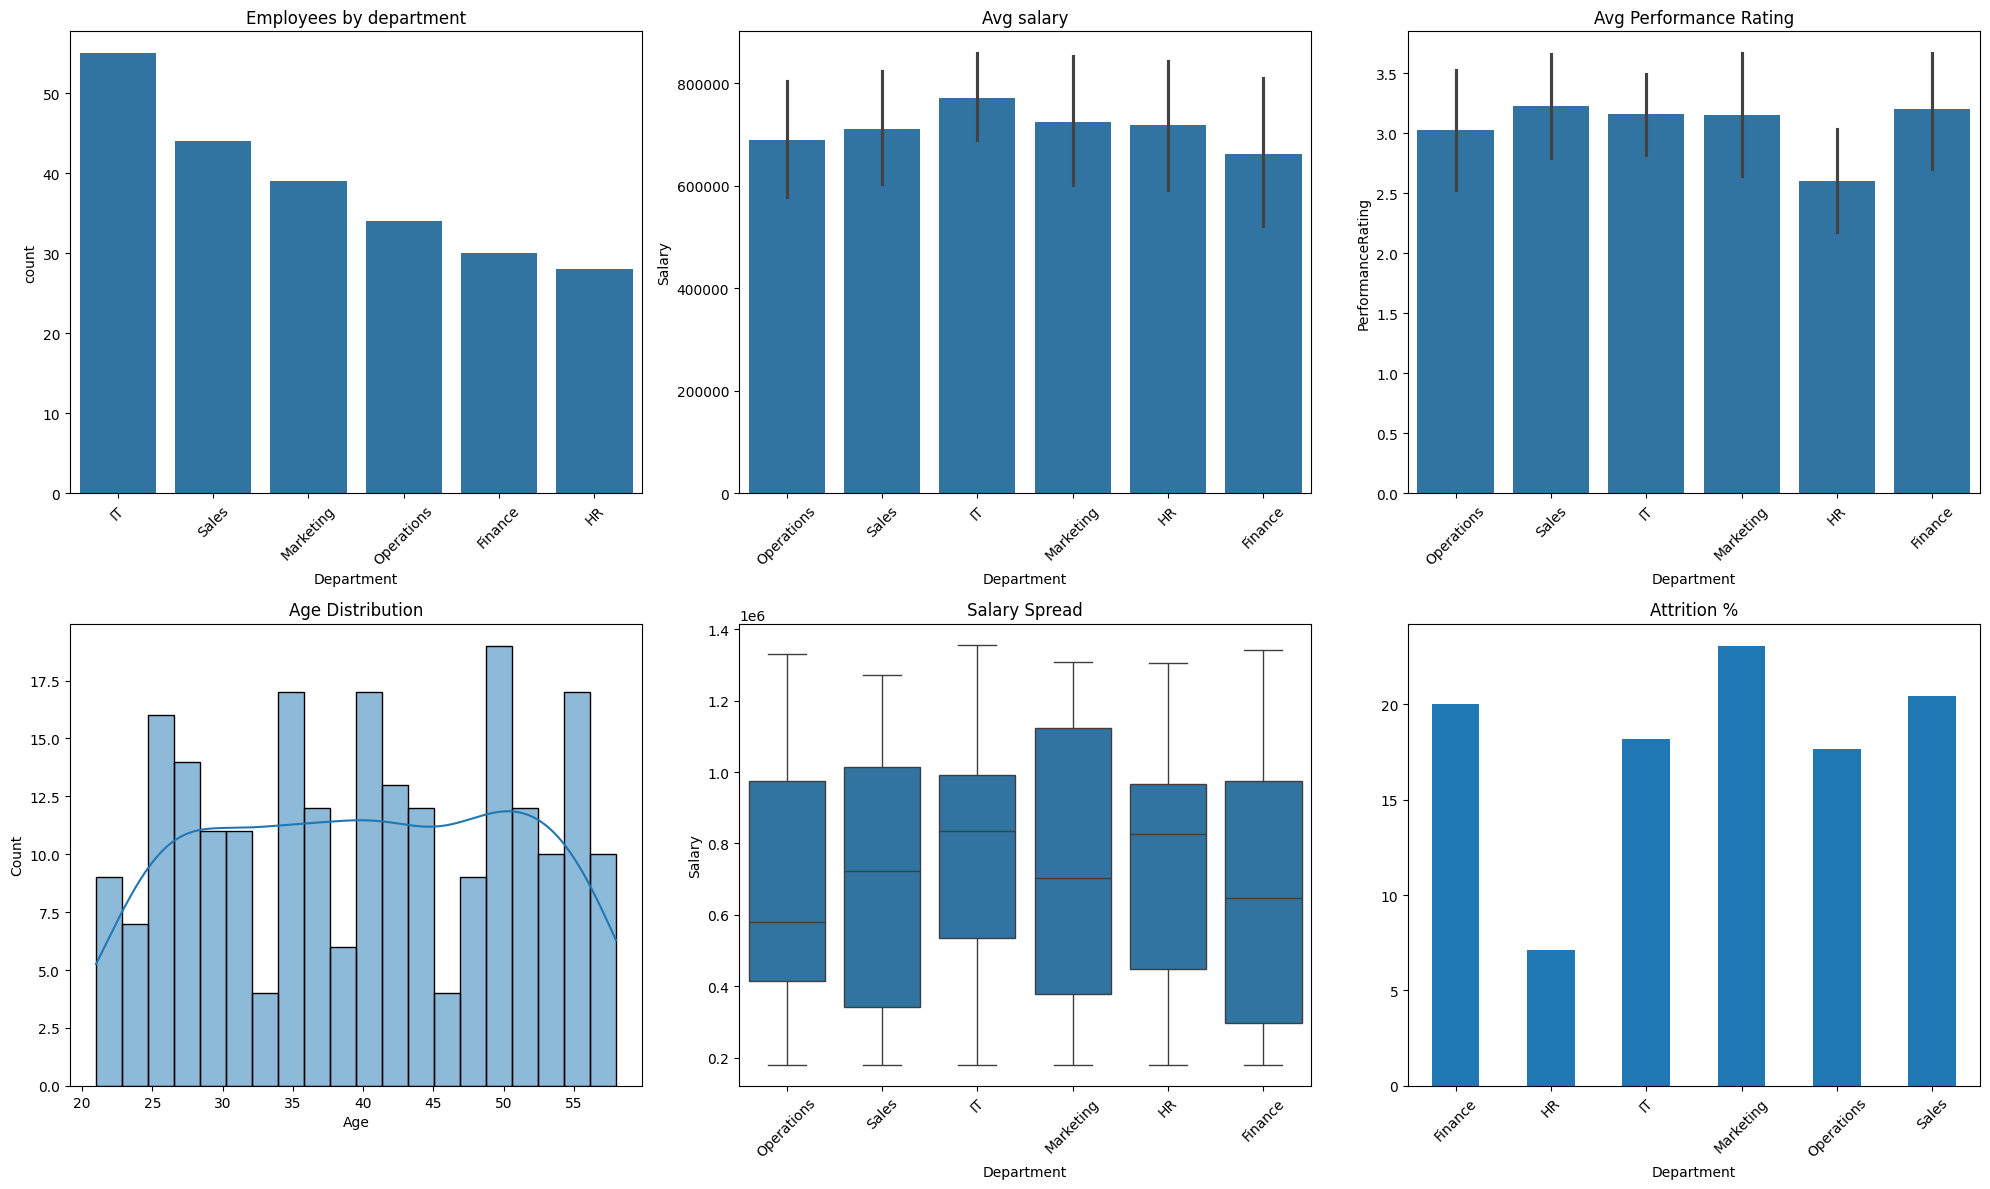

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(20,12))

#1
plt.subplot(2,3,1)
sns.countplot(
    data=df,
    x='Department',
    order=df['Department'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Employees by department")


#2

plt.subplot(2,3,2)

sns.barplot(data=df,
            x='Department',
            y='Salary',
            estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Avg salary")

#3

plt.subplot(2,3,3)
sns.barplot(data=df,
            x= 'Department',
            y='PerformanceRating',
            estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Avg Performance Rating")

#4
plt.subplot(2,3,4)

sns.histplot(df['Age'],bins=20,kde=True)
plt.title("Age Distribution")

#5
plt.subplot(2,3,5)
sns.boxplot(data=df,
            x="Department",
            y='Salary')
plt.xticks(rotation=45)
plt.title("Salary Spread")

#6
plt.subplot(2,3,6)
attr = df.groupby('Department')['Attrited'].mean()*100
attr.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Attrition %")


plt.tight_layout()
plt.show()